In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Đọc dữ liệu
df = pd.read_excel('data_nckh.xlsx')

# Chuyển cột "Time" thành datetime
df['Time'] = pd.to_datetime(df['Time'], format='%d/%m/%Y')

df = df.sort_values('Time').reset_index(drop=True)
df.set_index('Time', inplace=True)
# Lấy các biến độc lập (features) và biến mục tiêu (Gold_Price_VN)
target_col = "Gold_Price_VN"
feature_cols = ['CPI_VN', 'Gold_Price_World', 'Oil_Price', 'Tỷ giá USD/VND', 'SX_CN', 
            'VN-Index', 'CPI_USA', 'SM_M2', 'INTEREST_RATE', 'GSI', 'GSI_VN']

# Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])
df[target_col] = scaler.fit_transform(df[[target_col]])

# Chuẩn bị dữ liệu cho mô hình
features = df[feature_cols].values
target = df[target_col].values

# Phân chia dữ liệu thành training và test set
X_train, X_test, y_train, y_test = train_test_split(features, target, shuffle=False, test_size=0.2)

In [9]:
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(3,1,1 ),seasonal_order=(3,1,1,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.7557024890123445
RMSE: 0.24012501674939954
MAE: 0.20150321234332352


In [3]:
# TEST 1-1-0
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(1,1,0),seasonal_order=(1,1,0,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: -4.195167980984683
RMSE: 1.107331576518396
MAE: 0.9632470190211634


In [4]:
# TEST 2-1-0
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(2,1,0),seasonal_order=(2,1,0,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.6616182881256423
RMSE: 0.28260596782065284
MAE: 0.21368884374006705


In [5]:
# TEST 3-1-0
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(3,1,0),seasonal_order=(3,1,0,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.764309046839363
RMSE: 0.23585731131036947
MAE: 0.19718424507349122


In [7]:
# TEST 1-1-1
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(1,1,1),seasonal_order=(1,1,1,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.7370150592668532
RMSE: 0.24913992374668126
MAE: 0.19948676571655652


In [8]:
# TEST 2-1-1
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(2,1,1),seasonal_order=(2,1,1,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.2330518843277265
RMSE: 0.4254621000773002
MAE: 0.3675526845393595


In [9]:
# TEST 1-1-2
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(1,1,2),seasonal_order=(1,1,2,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.6305565544101377
RMSE: 0.29529212835168706
MAE: 0.25058754806358746


In [10]:
# TEST 2-1-2
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(2,1,2),seasonal_order=(2,1,2,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.7325645061293047
RMSE: 0.25123920476259526
MAE: 0.21382896821978073


In [11]:
# TEST 3-1-2
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(3,1,2),seasonal_order=(3,1,2,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.7672963936363171
RMSE: 0.2343578170123897
MAE: 0.19129457905296482


In [12]:
# TEST 1-1-3
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(1,1,3),seasonal_order=(1,1,3,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.3593403819274801
RMSE: 0.38885846931651846
MAE: 0.3326514898768411


In [13]:
# TEST 2-1-3
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(2,1,3),seasonal_order=(2,1,3,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.7140253454366774
RMSE: 0.25980150292484805
MAE: 0.22014096077271203


In [14]:
# TEST 3-1-3
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(3,1,3),seasonal_order=(3,1,3,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.7676927967690655
RMSE: 0.23415812141860454
MAE: 0.1933316501032859


In [17]:
# TEST 0-1-1
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(0,1,1),seasonal_order=(0,1,1,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.6183401997788631
RMSE: 0.30013462204221525
MAE: 0.25366020846516957


In [3]:
# TEST 0-1-2
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(0,1,2),seasonal_order=(0,1,2,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.6132343452260953
RMSE: 0.3021355564564208
MAE: 0.2551147727619194


In [4]:
# TEST 0-1-3
# Chia tập train-test (80% train, 20% test) không xáo trộn
train_size = int(0.8 * len(features))
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = target[:train_size], target[train_size:]

# Xây dựng mô hình SARIMAX với các biến độc lập (exog)
model = SARIMAX(y_train, exog=X_train, order=(0,1,3),seasonal_order=(0,1,3,12))
model_fit = model.fit()

# Dự báo với mô hình SARIMAX
y_pred_sarimax = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae = mean_absolute_error(y_test, y_pred_sarimax)
r2 = r2_score(y_test, y_pred_sarimax)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2_score: 0.41399239670883337
RMSE: 0.37190285515147165
MAE: 0.31785249343763944


In [ ]:
import pandas as pd
import numpy as np
import pmdarima as pm
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Đọc dữ liệu
df = pd.read_excel('data_nckh.xlsx')

# Chuyển cột "Time" thành datetime và sắp xếp dữ liệu theo thời gian
df['Time'] = pd.to_datetime(df['Time'], format='%d/%m/%Y')
df = df.sort_values('Time').reset_index(drop=True)
df.set_index('Time', inplace=True)

# Phân tích mùa vụ (seasonal decomposition) để tính seasonal index
result_mul = seasonal_decompose(df['Gold_Price_VN'], model='multiplicative', period=12)
seasonal_index = result_mul.seasonal

# Thêm chỉ số mùa vụ vào dữ liệu gốc
df['seasonal_index'] = seasonal_index

# Chọn các cột độc lập (features) và cột mục tiêu (target)
target_col = "Gold_Price_VN"
feature_cols = ['CPI_VN', 'Gold_Price_World', 'Oil_Price', 'Tỷ giá USD/VND', 'SX_CN', 
                'VN-Index', 'CPI_USA', 'SM_M2', 'INTEREST_RATE', 'GSI', 'GSI_VN']

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])
df[target_col] = scaler.fit_transform(df[[target_col]])

# Chuẩn bị dữ liệu cho mô hình
X = df[feature_cols + ['seasonal_index']].values
y = df[target_col].values

# Phân chia dữ liệu thành training và test set
train_size = int(0.8 * len(df))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert data to float32 to reduce memory usage
y_train = y_train.astype(np.float32)
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)  # Ensure X_test is also float32 to reduce memory usage

# Sử dụng pmdarima.auto_arima để tự động lựa chọn mô hình ARIMA tối ưu
model = pm.auto_arima(y_train, exogenous=X_train, 
                      start_p=1, start_q=1,
                      test='adf',  # Kiểm tra ADF để chọn d
                      max_p=3, max_q=3, m=12,  # Thử các giá trị p, q
                      start_P=0, seasonal=True,
                      D=1, trace=True, stepwise=True, suppress_warnings=True)

# In thông tin mô hình tốt nhất
print(model.summary())

# Dự báo với mô hình ARIMA tối ưu
y_pred_arima = model.predict(n_periods=len(y_test), exogenous=X_test)

# Đánh giá mô hình với các chỉ số như RMSE, MAE, và R2
rmse = np.sqrt(mean_squared_error(y_test, y_pred_arima))
mae = mean_absolute_error(y_test, y_pred_arima)
r2 = r2_score(y_test, y_pred_arima)

print("R2_score:", r2)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=23.36 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-13266.710, Time=0.73 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-22323.848, Time=21.77 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-17159.007, Time=13.55 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-13207.547, Time=0.35 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=-21257.281, Time=1.02 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=-22801.367, Time=31.88 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=39.22 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=-23286.235, Time=29.73 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=inf, Time=22.78 sec
 ARIMA(1,0,0)(1,1,2)[12] intercept   : AIC=inf, Time=40.16 sec
 ARIMA(1,0,0)(0,1,2)[12] intercept   : AIC=inf, Time=33.66 sec
 ARIMA(1,0,0)(2,1,2)[12] intercept   : AIC=inf, Time=48.90 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=-13334.015, Time=16.23 sec
 ARIMA(2,0,0)(1,1,1)[1

Traceback (most recent call last):
  File "c:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py", line 2168, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\ultratb.py", line 1454, in structured_traceback
    return FormattedTB.structured_traceback(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\ultratb.py", line 1345, in structured_traceback
    return VerboseTB.structured_traceback(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\ultratb.py", line 1192, in structured_traceback
    formatted_exception = self.format_exception_as_a_whole(etype, evalue, etb, number_of_lines_of_context,
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\

In [2]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Function to apply differencing and calculate ADF test statistic
def adf_test(series, max_d=3):
    results = {}
    for d in range(max_d + 1):
        diff_series = series.diff(d).dropna()  # Perform differencing
        # Check if the series is constant
        if diff_series.nunique() > 1:
            result = adfuller(diff_series)  # ADF test
            results[d] = {
                'ADF Statistic': result[0],
                'p-value': result[1]
            }
        else:
            results[d] = {
                'ADF Statistic': None,
                'p-value': None,
                'Error': 'Series is constant'
            }
    return results

# Load the data from the uploaded Excel file
file_path = 'data_nckh.xlsx'
data = pd.read_excel(file_path)

# Apply the ADF test for the Gold_Price_VN variable
results = adf_test(data['Gold_Price_VN'], max_d=3)

# Display the results
for d, res in results.items():
    print(f"Difference order {d}: ADF Statistic = {res['ADF Statistic']}, p-value = {res['p-value']}")

Difference order 0: ADF Statistic = None, p-value = None
Difference order 1: ADF Statistic = -12.68176912899176, p-value = 1.182747103459847e-23
Difference order 2: ADF Statistic = -12.55313371316794, p-value = 2.1836247371088838e-23
Difference order 3: ADF Statistic = -11.569656129806512, p-value = 3.1244884716299162e-21


### Chọn d = 1
==> Chọn p-value < 0.05 và ADF nhỏ nhất

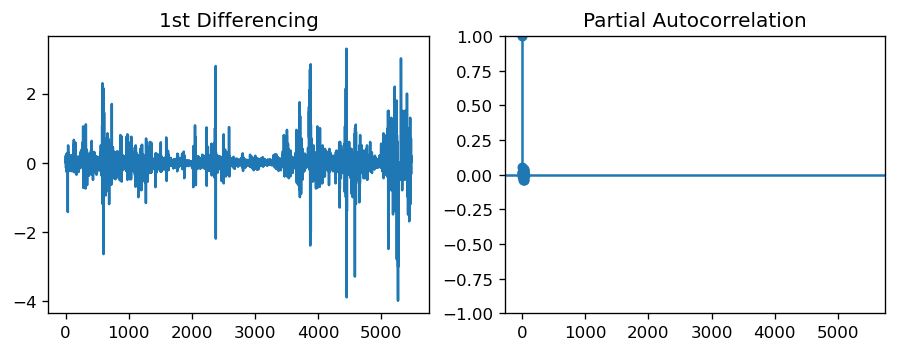

In [3]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Assume df['Gold_Price_VN'] is the time series variable
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

# Create the first differenced series
diff_series = data['Gold_Price_VN'].diff().dropna()

# Plotting PACF
fig, axes = plt.subplots(1, 2, sharex=True)
axes[0].plot(diff_series); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0, 5))
plot_pacf(diff_series, ax=axes[1])

plt.show()


### Chọn p = 1
==> Độ trễ p=1 là độ trễ đầu tiên có giá trị PACF vượt quá ngưỡng, và sau đó các độ trễ tiếp theo không có giá trị đáng kể nữa.

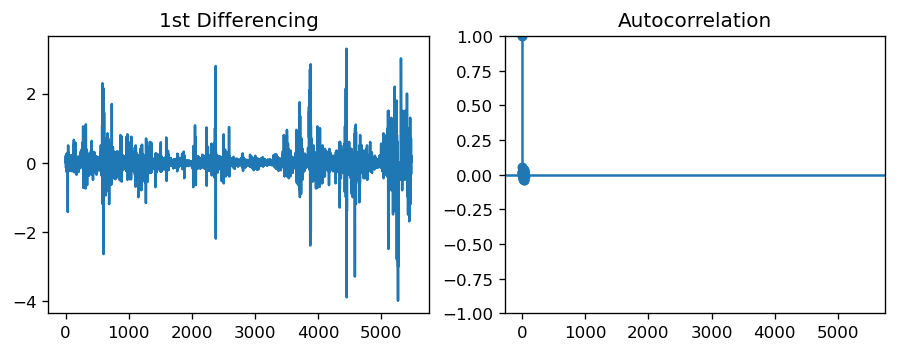

In [4]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Assume df['Gold_Price_VN'] is the time series variable
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

# Create the first differenced series
diff_series = data['Gold_Price_VN'].diff().dropna()

# Plotting ACF
fig, axes = plt.subplots(1, 2, sharex=True)
axes[0].plot(diff_series); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0, 1.2))
plot_acf(diff_series, ax=axes[1])

plt.show()

# q = 0